# Visualisierungen

In [36]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [37]:
df_final = pd.read_csv("data/final_data_groups/df_final.csv")

In [38]:
df_final

,user_id,gender,married,has_children,home_country,home_city,home_airport,age,sign_up_year,states,...,average_nights,total_flight_cost,total_hotels_cost,avg_clicks,avg_distance_user,clicks_per_min,avg_session_dauer,trips_per_session,total_spent,group
0,94883,F,True,False,usa,kansas city,MCI,51,2022,Missouri,...,1.000000,5354.8600,230.00,8.333333,1060.930335,8.042895,1.036111,0.250000,5584.8600,VIPs
1,101486,F,True,True,usa,tacoma,TCM,50,2022,Washington,...,3.333333,351.7425,2277.05,26.153846,2094.397252,2.379286,10.992308,0.230769,2628.7925,Long-Distance Travelers
2,101961,F,True,False,usa,boston,BOS,43,2022,Massachusetts,...,3.285714,1924.2330,2550.40,18.166667,2436.512974,8.049231,2.256944,0.583333,4474.6330,VIPs
3,106907,F,True,True,usa,miami,TNT,44,2022,Florida,...,6.000000,165.5100,2231.00,26.285714,2061.557769,3.142023,8.365858,0.142857,2396.5100,Long-Distance Travelers
4,118043,F,False,True,usa,los angeles,LAX,51,2022,California,...,5.500000,2339.2900,5811.00,16.153846,623.381115,4.274937,3.778733,0.384615,8150.2900,VIPs
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5777,770252,F,False,False,usa,oakland,OAK,24,2023,California,...,NaN,NaN,NaN,36.500000,795.942662,2.223068,16.418750,0.000000,NaN,Budget & Occasional Travelers
5778,785186,F,True,True,usa,little rock,LIT,44,2023,Arkansas,...,1.000000,353.3500,291.00,21.625000,263.178203,8.052754,2.685417,0.250000,644.3500,Budget & Occasional Travelers
5779,792549,F,False,False,usa,kansas city,MCI,45,2023,Missouri,...,4.000000,1039.1700,136.80,14.250000,719.002463,8.000000,1.781250,0.500000,1175.9700,Frequent Travelers
5780,811077,F,True,True,usa,knoxville,TYS,44,2023,Tennessee,...,6.000000,579.7900,852.00,13.125000,398.104421,7.944515,1.652083,0.125000,1431.7900,Budget & Occasional Travelers


In [39]:
df_final.columns

Index(['user_id', 'gender', 'married', 'has_children', 'home_country',
       'home_city', 'home_airport', 'age', 'sign_up_year', 'states',
       'num_session', 'num_trips', 'num_flights', 'num_hotels',
       'booking_discount_rate', 'average_seats', 'average_checked_bags',
       'average_seats_price', 'weekend_trip_ratio', 'average_nights',
       'total_flight_cost', 'total_hotels_cost', 'avg_clicks',
       'avg_distance_user', 'clicks_per_min', 'avg_session_dauer',
       'trips_per_session', 'total_spent', 'group'],
      dtype='str')

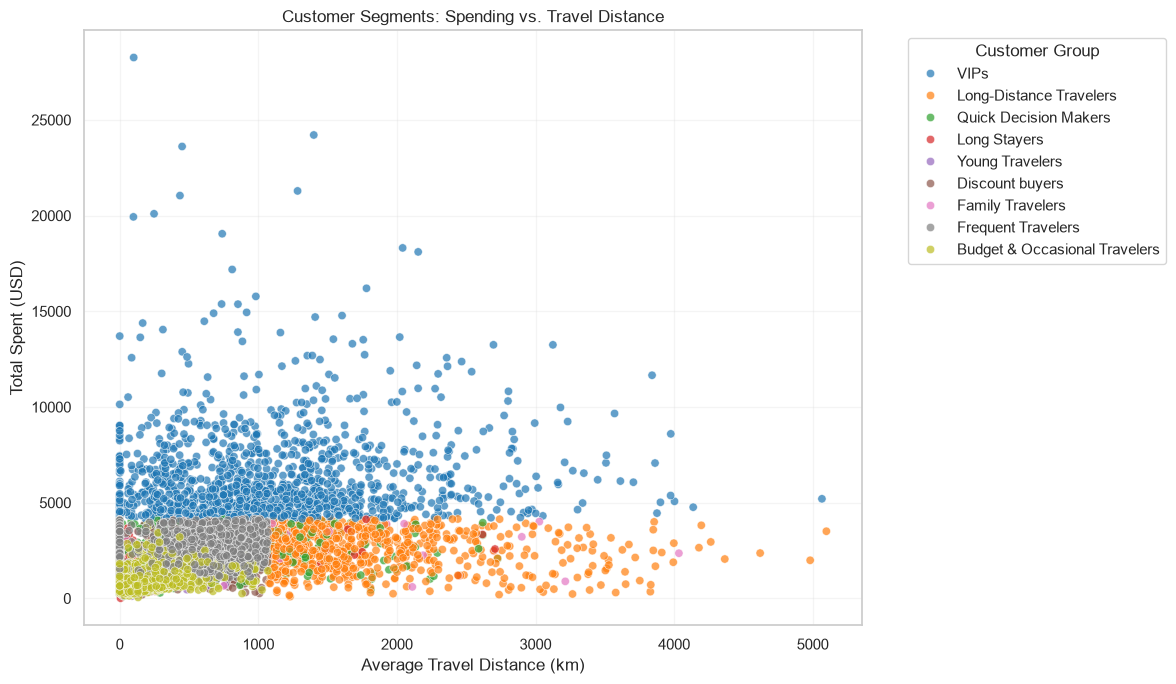

In [55]:
plt.figure(figsize=(12, 7))

sns.scatterplot(
    data=df_final,
    x="avg_distance_user",
    y="total_spent",
    hue="group",
    alpha=0.7,
    palette="tab10"
)

plt.title("Customer Segments: Spending vs. Travel Distance")
plt.xlabel("Average Travel Distance (km)")
plt.ylabel("Total Spent (USD)")
plt.legend(
    title="Customer Group",
    bbox_to_anchor=(1.05, 1),
    loc="upper left"
)

plt.grid(alpha=0.2)
plt.tight_layout()

plt.show()

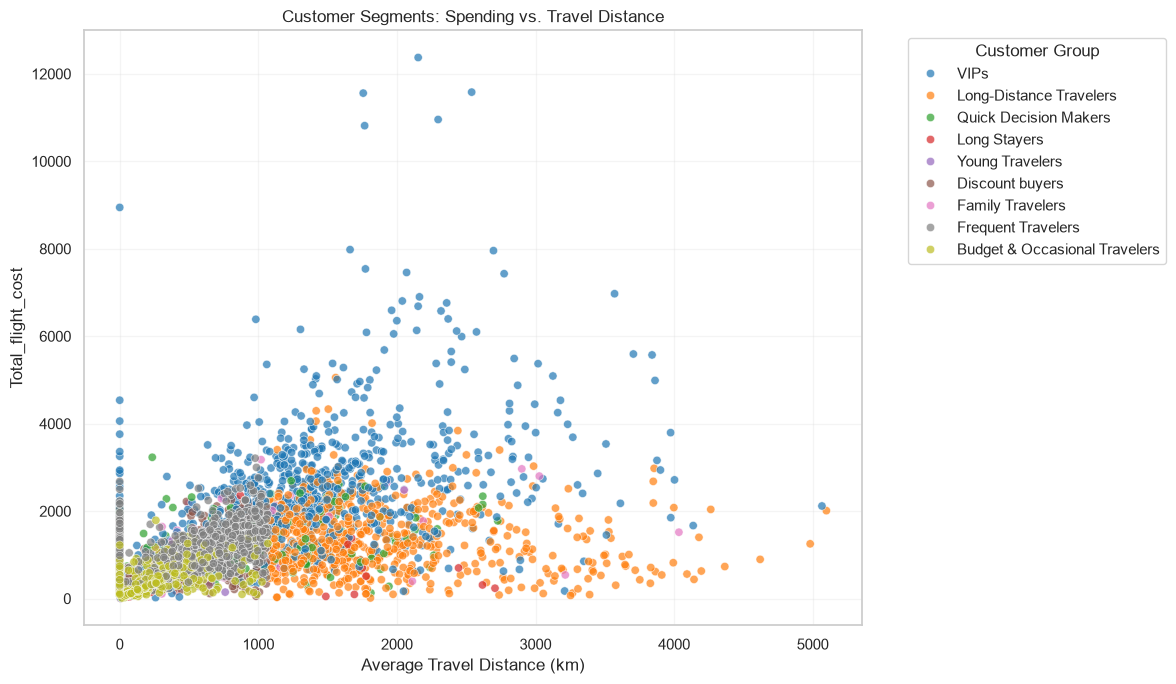

In [56]:
plt.figure(figsize=(12, 7))

sns.scatterplot(
    data=df_final,
    x="avg_distance_user",
    y="total_flight_cost",
    hue="group",
    alpha=0.7,
    palette="tab10"
)

plt.title("Customer Segments: Spending vs. Travel Distance")
plt.xlabel("Average Travel Distance (km)")
plt.ylabel("Total_flight_cost")
plt.legend(
    title="Customer Group",
    bbox_to_anchor=(1.05, 1),
    loc="upper left"
)

plt.grid(alpha=0.2)
plt.tight_layout()

plt.show()

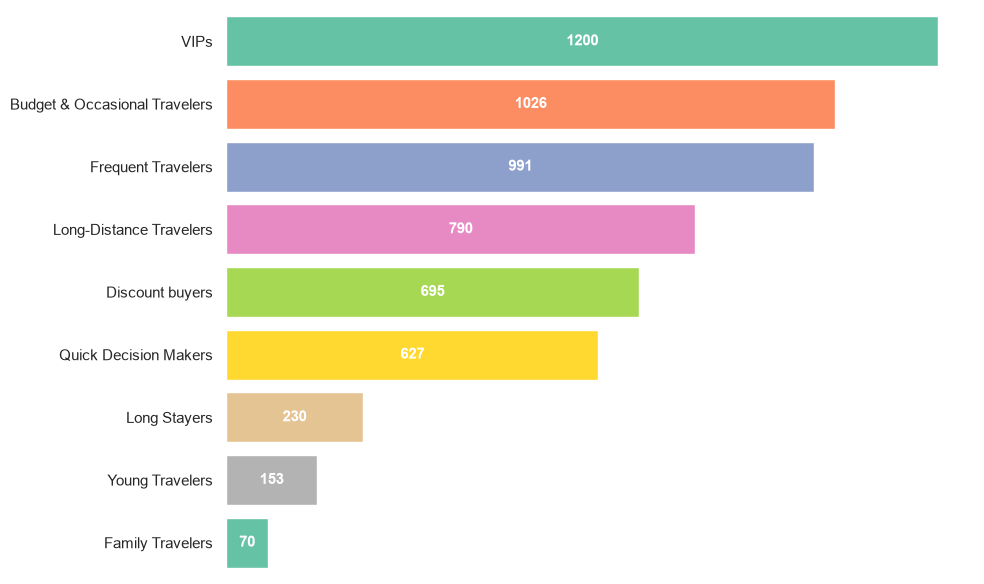

In [53]:
import seaborn as sns
import matplotlib.pyplot as plt

# Reihenfolge nach Häufigkeit
order = df_final["group"].value_counts().index

# Für jede Gruppe eine eigene Farbe
farben = sns.color_palette("Set2", n_colors=len(order))

plt.figure(figsize=(10, 6))

ax = sns.countplot(
    data=df_final,
    y="group",
    order=order,
    color="gray"
)

# Jeden Balken individuell einfärben
for bar, farbe in zip(ax.patches, farben):
    bar.set_facecolor(farbe)

    # Anzahl der Kunden
    anzahl = int(bar.get_width())

    # Zahl in den Balken schreiben
    ax.text(
        bar.get_width() / 2,
        bar.get_y() + bar.get_height() / 2,
        str(anzahl),
        ha="center",
        va="center",
        color="white",
        fontweight="bold",
        fontsize=11
    )

# Rasterlinien entfernen
ax.grid(False)

# Diagrammrahmen entfernen
for spine in ax.spines.values():
    spine.set_visible(False)

# Titel und Achsenbeschriftungen entfernen
ax.set_title("")
ax.set_xlabel("")
ax.set_ylabel("")

# Zahlen der x-Achse unten entfernen
ax.set_xticks([])

plt.tight_layout()
plt.show()

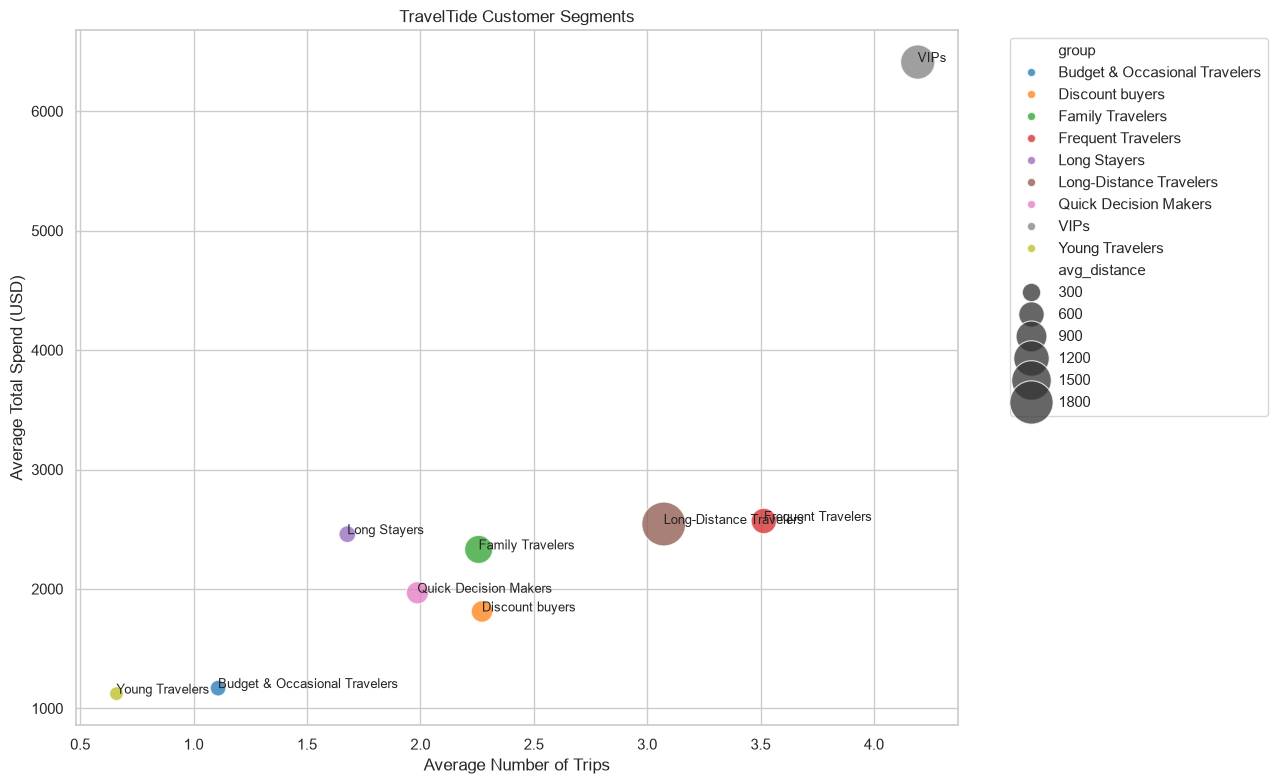

In [63]:
group_summary = df_final.groupby("group").agg(
    avg_trips=("num_trips", "mean"),
    avg_spent=("total_spent", "mean"),
    avg_distance=("avg_distance_user", "mean")
).reset_index()

plt.figure(figsize=(13, 8))

sns.scatterplot(
    data=group_summary,
    x="avg_trips",
    y="avg_spent",
    size="avg_distance",
    hue="group",
    sizes=(100, 1000),
    alpha=0.75,
    palette="tab10"
)

for _, row in group_summary.iterrows():
    plt.text(
        row["avg_trips"],
        row["avg_spent"],
        row["group"],
        fontsize=9
    )

plt.title("TravelTide Customer Segments")
plt.xlabel("Average Number of Trips")
plt.ylabel("Average Total Spend (USD)")

plt.legend(
    bbox_to_anchor=(1.05, 1),
    loc="upper left"
)

plt.tight_layout()
plt.show()

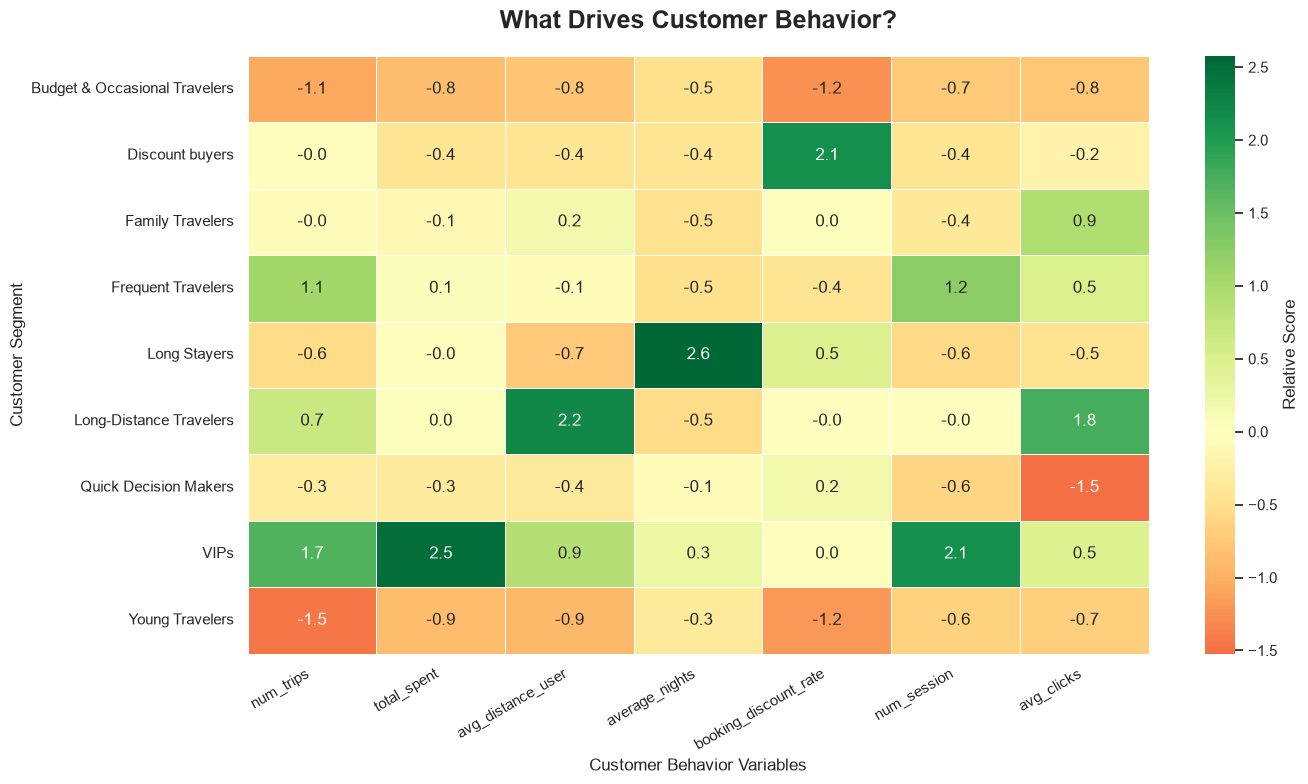

In [65]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Variablen für die Segmentanalyse
variables = [
    "num_trips",
    "total_spent",
    "avg_distance_user",
    "average_nights",
    "booking_discount_rate",
    "num_session",
    "avg_clicks"
]

# Durchschnittswerte pro Gruppe berechnen
group_summary = (
    df_final.groupby("group")[variables]
    .mean()
)

# Standardisierung:
# Dadurch sind z.B. USD, Kilometer und Anzahl Sessions vergleichbar.
group_summary_scaled = (
    group_summary - group_summary.mean()
) / group_summary.std()

# Heatmap
plt.figure(figsize=(14, 8))

sns.heatmap(
    group_summary_scaled,
    annot=True,
    fmt=".1f",
    cmap="RdYlGn",
    center=0,
    linewidths=0.5,
    cbar_kws={"label": "Relative Score"}
)

plt.title(
    "What Drives Customer Behavior?",
    fontsize=18,
    fontweight="bold",
    pad=20
)

plt.xlabel("Customer Behavior Variables", fontsize=12)
plt.ylabel("Customer Segment", fontsize=12)

plt.xticks(rotation=30, ha="right")
plt.yticks(rotation=0)

plt.tight_layout()
plt.show()